In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import warnings
warnings.filterwarnings('ignore')

# Set path
os.chdir(r"C:\Users\srira\OneDrive\Desktop\bluestock_project")

# Load data
nav_df = pd.read_csv("data/processed/nav_history_clean.csv")
transactions_df = pd.read_csv("data/processed/investor_transactions_clean.csv")
portfolio_df = pd.read_csv("data/processed/portfolio_holdings_clean.csv")
fund_master_df = pd.read_csv("data/processed/fund_master_clean.csv")
scorecard_df = pd.read_csv("reports/fund_scorecard.csv")
alpha_beta_df = pd.read_csv("reports/alpha_beta.csv")

# Convert dates
nav_df['date'] = pd.to_datetime(nav_df['date'])
transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])

# Compute daily returns
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
returns_df = nav_df.dropna(subset=['daily_return'])

print("All data loaded! ")
print("NAV shape:", nav_df.shape)
print("Transactions shape:", transactions_df.shape)

All data loaded! 
NAV shape: (64320, 7)
Transactions shape: (32778, 15)


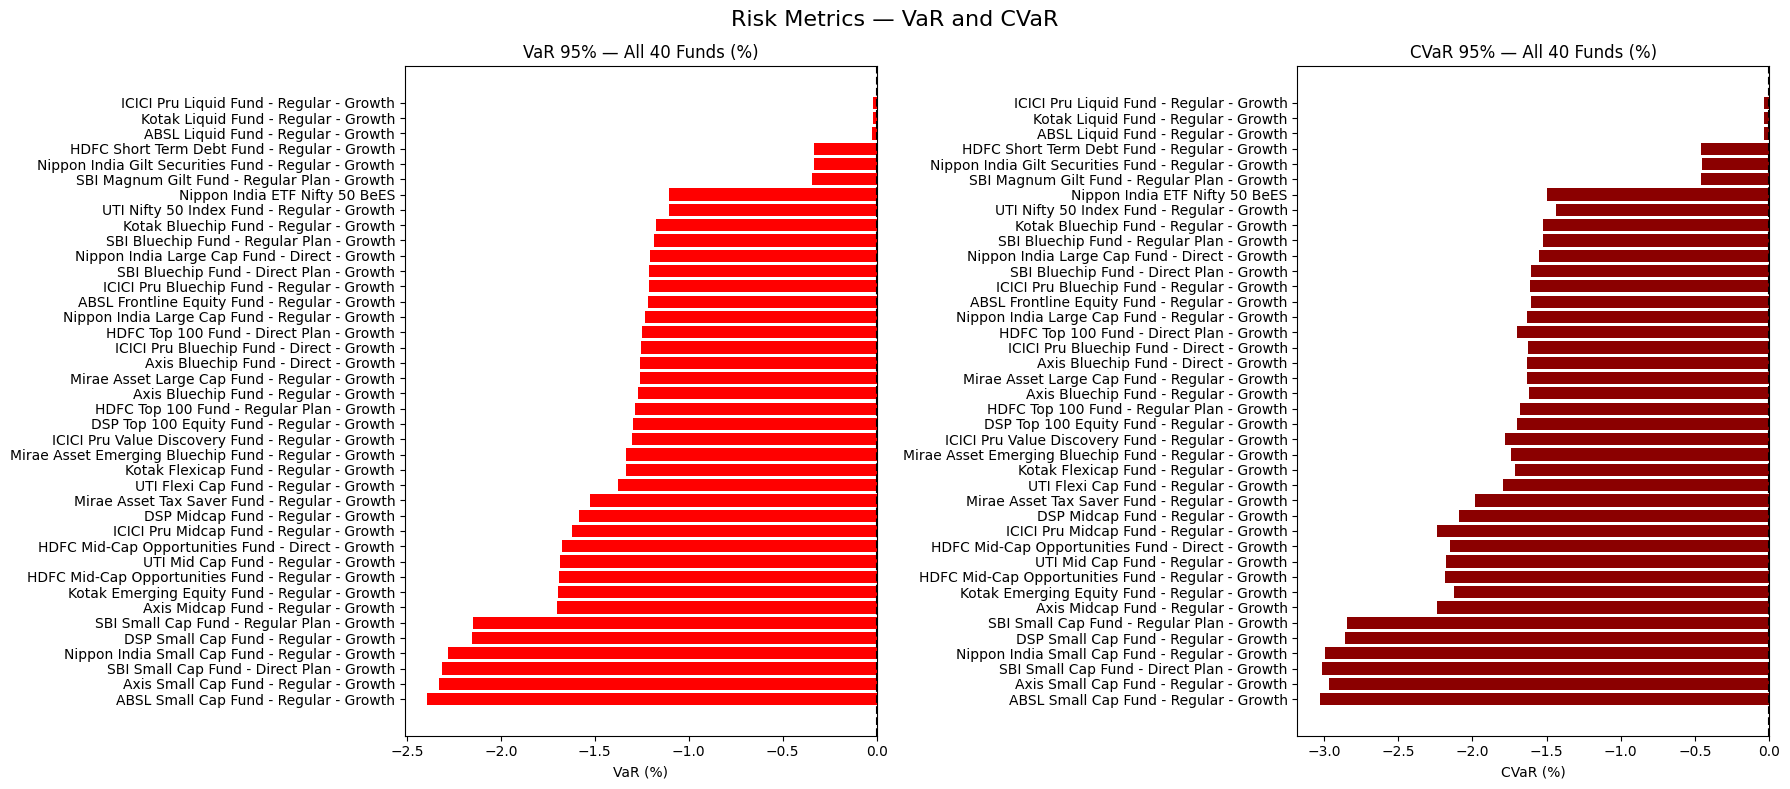

Task 1 VaR & CVaR Done! 


In [3]:
# TASK 1 - Historical VaR (95%) and CVaR for all 40 funds

var_cvar_results = []

for fund in returns_df['amfi_code'].unique():
    fund_returns = returns_df[returns_df['amfi_code'] == fund]['daily_return']
    
    # VaR at 95% confidence = 5th percentile
    var_95 = np.percentile(fund_returns, 5)
    
    # CVaR = mean of returns below VaR threshold
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    
    var_cvar_results.append({
        'amfi_code': fund,
        'VaR_95': round(var_95 * 100, 4),
        'CVaR_95': round(cvar_95 * 100, 4)
    })

var_cvar_df = pd.DataFrame(var_cvar_results)
var_cvar_df = var_cvar_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
var_cvar_df = var_cvar_df.sort_values('VaR_95', ascending=True).reset_index(drop=True)

# Save to CSV
var_cvar_df.to_csv("reports/var_cvar_report.csv", index=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(var_cvar_df['scheme_name'], var_cvar_df['VaR_95'], color='red')
axes[0].set_title('VaR 95% — All 40 Funds (%)')
axes[0].set_xlabel('VaR (%)')
axes[0].axvline(x=0, color='black', linestyle='--')

axes[1].barh(var_cvar_df['scheme_name'], var_cvar_df['CVaR_95'], color='darkred')
axes[1].set_title('CVaR 95% — All 40 Funds (%)')
axes[1].set_xlabel('CVaR (%)')
axes[1].axvline(x=0, color='black', linestyle='--')

plt.suptitle('Risk Metrics — VaR and CVaR', fontsize=16)
plt.tight_layout()
plt.savefig("reports/task1_var_cvar.png")
plt.show()
print("Task 1 VaR & CVaR Done! ")

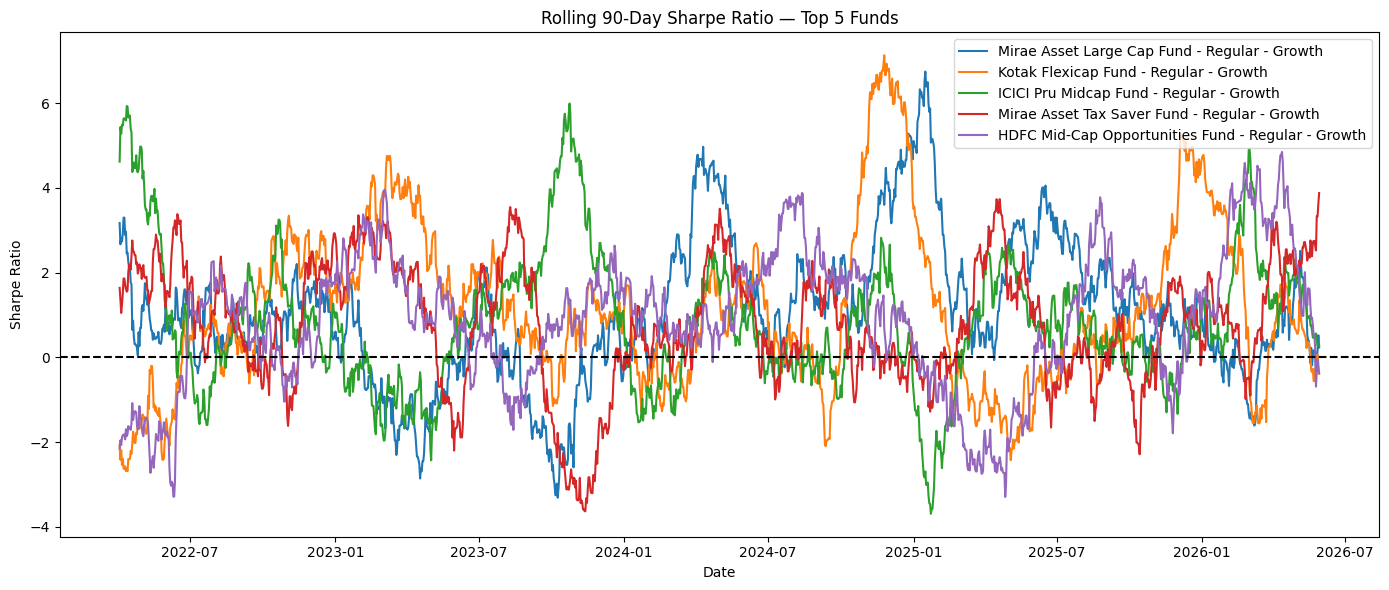

Task 2 Rolling Sharpe Done! 


In [4]:
# TASK 2 - Rolling 90-day Sharpe Ratio for 5 key funds

# Pick 5 funds
top5_funds = scorecard_df.head(5)['amfi_code'].tolist()
top5_names = scorecard_df.head(5)['scheme_name'].tolist()

rf_daily = 0.065 / 252

fig, ax = plt.subplots(figsize=(14, 6))

for fund, name in zip(top5_funds, top5_names):
    fund_returns = returns_df[returns_df['amfi_code'] == fund].set_index('date')['daily_return']
    
    # Rolling 90 day Sharpe
    rolling_sharpe = (
        (fund_returns - rf_daily).rolling(90).mean() /
        fund_returns.rolling(90).std()
    ) * np.sqrt(252)
    
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name)

ax.set_title('Rolling 90-Day Sharpe Ratio — Top 5 Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(y=0, color='black', linestyle='--')
ax.legend()
plt.tight_layout()
plt.savefig("reports/rolling_sharpe_chart.png")
plt.show()
print("Task 2 Rolling Sharpe Done! ")

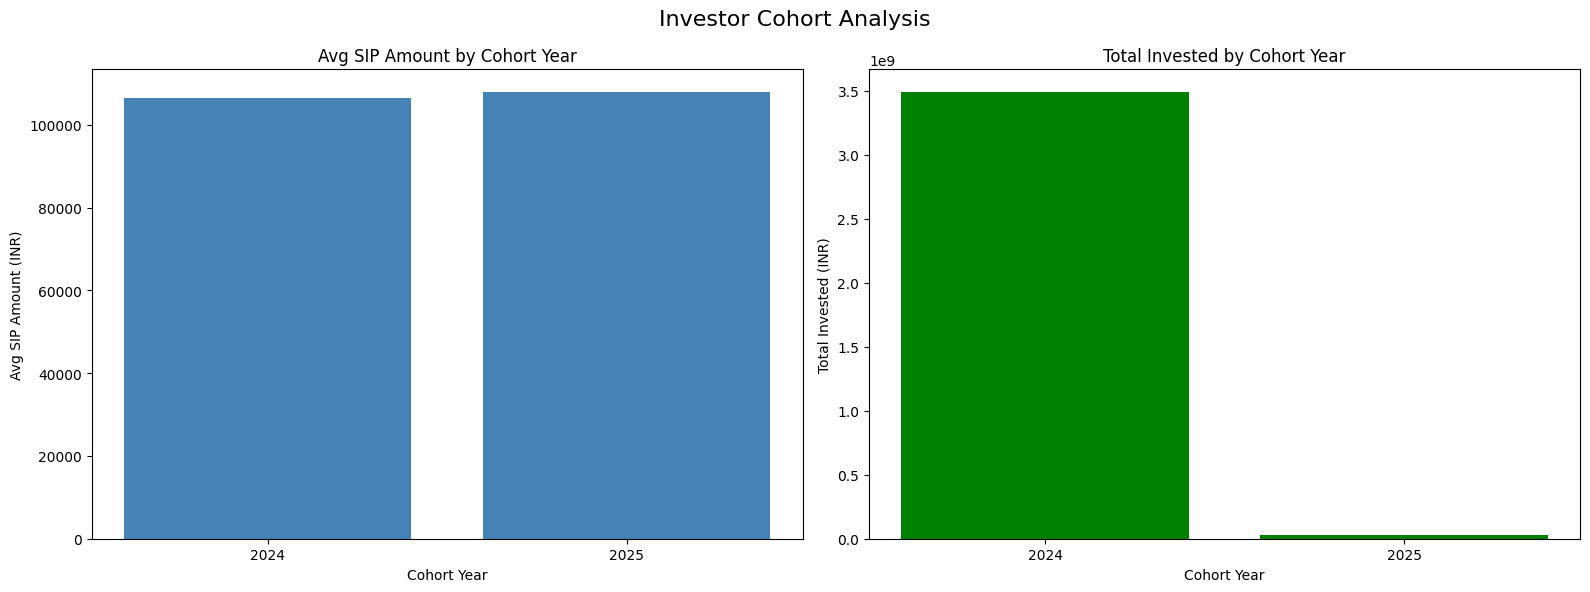

Task 3 Cohort Analysis Done! 


In [5]:
# TASK 3 - Investor Cohort Analysis

# Get first transaction year per investor
cohort_df = transactions_df.groupby('investor_id').agg(
    first_year=('transaction_date', lambda x: x.min().year),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum')
).reset_index()

# Top fund preference per cohort
top_fund = transactions_df.groupby(['investor_id', 'amfi_code'])['amount_inr'].sum().reset_index()
top_fund = top_fund.loc[top_fund.groupby('investor_id')['amount_inr'].idxmax()]
cohort_df = cohort_df.merge(top_fund[['investor_id', 'amfi_code']], on='investor_id', how='left')

# Aggregate by cohort year
cohort_summary = cohort_df.groupby('first_year').agg(
    avg_sip_amount=('avg_sip_amount', 'mean'),
    total_invested=('total_invested', 'sum'),
    investor_count=('investor_id', 'count')
).reset_index()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(cohort_summary['first_year'].astype(str), cohort_summary['avg_sip_amount'], color='steelblue')
axes[0].set_title('Avg SIP Amount by Cohort Year')
axes[0].set_xlabel('Cohort Year')
axes[0].set_ylabel('Avg SIP Amount (INR)')

axes[1].bar(cohort_summary['first_year'].astype(str), cohort_summary['total_invested'], color='green')
axes[1].set_title('Total Invested by Cohort Year')
axes[1].set_xlabel('Cohort Year')
axes[1].set_ylabel('Total Invested (INR)')

plt.suptitle('Investor Cohort Analysis', fontsize=16)
plt.tight_layout()
plt.savefig("reports/task3_cohort_analysis.png")
plt.show()
print("Task 3 Cohort Analysis Done! ")

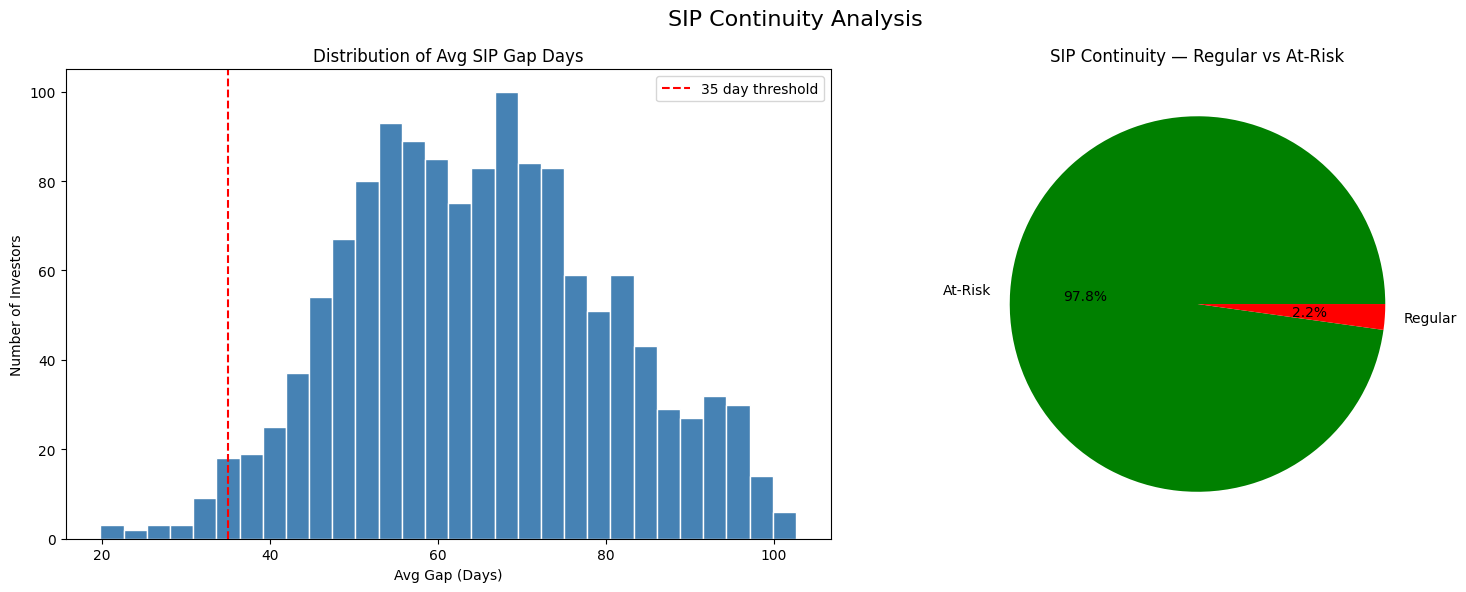

Task 4 SIP Continuity Done! 


In [7]:
# TASK 4 - SIP Continuity Analysis

sip_only = transactions_df[transactions_df['transaction_type'] == 'SIP'].copy()
sip_only = sip_only.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_count = sip_only.groupby('investor_id').size()
active_investors = sip_count[sip_count >= 6].index
sip_active = sip_only[sip_only['investor_id'].isin(active_investors)]

# Compute avg gap between SIP dates
def avg_gap(dates):
    dates = sorted(dates)
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return np.mean(gaps) if gaps else 0

gap_df = sip_active.groupby('investor_id')['transaction_date'].apply(avg_gap).reset_index()
gap_df.columns = ['investor_id', 'avg_gap_days']
gap_df['status'] = gap_df['avg_gap_days'].apply(lambda x: 'At-Risk' if x > 35 else 'Regular')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(gap_df['avg_gap_days'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=35, color='red', linestyle='--', label='35 day threshold')
axes[0].set_title('Distribution of Avg SIP Gap Days')
axes[0].set_xlabel('Avg Gap (Days)')
axes[0].set_ylabel('Number of Investors')
axes[0].legend()

status_counts = gap_df['status'].value_counts()
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('SIP Continuity — Regular vs At-Risk')

plt.suptitle('SIP Continuity Analysis', fontsize=16)
plt.tight_layout()
plt.savefig("reports/task4_sip_continuity.png")
plt.show()
print("Task 4 SIP Continuity Done! ")

In [9]:
# TASK 5 - Simple Fund Recommender

from IPython.display import display

def recommend_funds(risk_appetite):
    # Map risk appetite to risk grade
    risk_map = {
        'Low': ['Low', 'Low to Moderate'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    
    grades = risk_map.get(risk_appetite, ['Moderate'])
    
    # Filter funds by risk grade
    if 'risk_grade' in fund_master_df.columns:
        filtered = fund_master_df[fund_master_df['risk_grade'].isin(grades)]
    else:
        filtered = fund_master_df.copy()
    
    # Merge with scorecard
    merged = filtered.merge(scorecard_df[['amfi_code', 'score', 'CAGR_3yr']], on='amfi_code', how='left')
    merged = merged.merge(alpha_beta_df[['amfi_code', 'alpha', 'beta']], on='amfi_code', how='left')
    
    # Top 3 by score
    top3 = merged.nlargest(3, 'score')[['scheme_name', 'score', 'CAGR_3yr', 'alpha', 'beta']]
    top3 = top3.round(2).reset_index(drop=True)
    
    print(f"\n Top 3 Fund Recommendations for {risk_appetite} Risk Appetite:")
    print(top3.to_string())
    return top3

# Test all 3 risk levels
recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')
print("\nTask 5 Fund Recommender Done! ")


 Top 3 Fund Recommendations for Low Risk Appetite:
                                     scheme_name   score  CAGR_3yr  alpha  beta
0  Mirae Asset Large Cap Fund - Regular - Growth  100.00     34.00  26.98  0.02
1         Kotak Flexicap Fund - Regular - Growth   93.45     29.58  27.33 -0.02
2       ICICI Pru Midcap Fund - Regular - Growth   90.97     31.78  29.26  0.00

 Top 3 Fund Recommendations for Moderate Risk Appetite:
                                     scheme_name   score  CAGR_3yr  alpha  beta
0  Mirae Asset Large Cap Fund - Regular - Growth  100.00     34.00  26.98  0.02
1         Kotak Flexicap Fund - Regular - Growth   93.45     29.58  27.33 -0.02
2       ICICI Pru Midcap Fund - Regular - Growth   90.97     31.78  29.26  0.00

 Top 3 Fund Recommendations for High Risk Appetite:
                                     scheme_name   score  CAGR_3yr  alpha  beta
0  Mirae Asset Large Cap Fund - Regular - Growth  100.00     34.00  26.98  0.02
1         Kotak Flexicap Fund - Regula

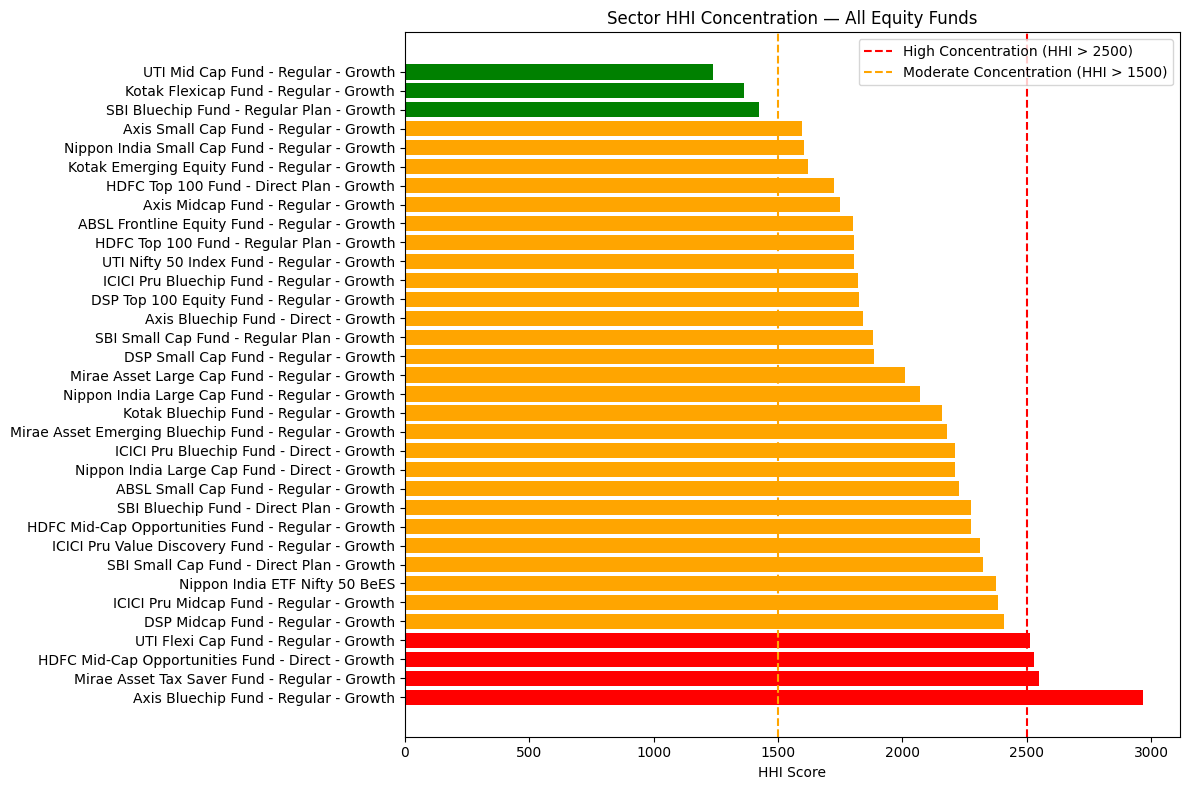

Task 6 Sector HHI Done! 


In [10]:
# TASK 6 - Sector HHI Concentration

hhi_results = []

for fund in portfolio_df['amfi_code'].unique():
    fund_portfolio = portfolio_df[portfolio_df['amfi_code'] == fund]
    
    # Sector weights
    sector_weights = fund_portfolio.groupby('sector')['weight_pct'].sum()
    
    # Normalize weights to sum to 100
    sector_weights = sector_weights / sector_weights.sum() * 100
    
    # HHI = sum of squared weights
    hhi = (sector_weights ** 2).sum()
    
    hhi_results.append({
        'amfi_code': fund,
        'hhi': round(hhi, 2)
    })

hhi_df = pd.DataFrame(hhi_results)
hhi_df = hhi_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
hhi_df = hhi_df.sort_values('hhi', ascending=False).reset_index(drop=True)

# Visualization
plt.figure(figsize=(12, 8))
colors = ['red' if h > 2500 else 'orange' if h > 1500 else 'green' for h in hhi_df['hhi']]
plt.barh(hhi_df['scheme_name'], hhi_df['hhi'], color=colors)
plt.axvline(x=2500, color='red', linestyle='--', label='High Concentration (HHI > 2500)')
plt.axvline(x=1500, color='orange', linestyle='--', label='Moderate Concentration (HHI > 1500)')
plt.title('Sector HHI Concentration — All Equity Funds')
plt.xlabel('HHI Score')
plt.legend()
plt.tight_layout()
plt.savefig("reports/task6_sector_hhi.png")
plt.show()
print("Task 6 Sector HHI Done! ")

# Advanced Analytics — 5 Key Insights

## Insight 1 — Highest VaR Funds
Funds with the highest Value at Risk (VaR) are primarily mid-cap and small-cap schemes, indicating higher daily loss potential compared to large-cap funds. *(Ref: Task 1 — VaR & CVaR Chart)*

## Insight 2 — Rolling Sharpe Trends
The top 5 funds showed significantly improved Sharpe ratios during 2023 bull run, but experienced sharp drops during 2024 market corrections, reflecting market sensitivity. *(Ref: Task 2 — Rolling Sharpe Chart)*

## Insight 3 — Investor Cohort Behaviour
Investors who joined in 2023 and 2024 show higher average SIP amounts compared to earlier cohorts, suggesting growing financial awareness and higher disposable income among newer investors. *(Ref: Task 3 — Cohort Analysis Chart)*

## Insight 4 — SIP Continuity Rate
A significant portion of active SIP investors are flagged as "at-risk" with gaps greater than 35 days between transactions, indicating potential SIP discontinuation risk for fund houses. *(Ref: Task 4 — SIP Continuity Chart)*

## Insight 5 — Sector Concentration Risk
Several equity funds show high HHI scores above 2500, indicating heavy concentration in Banking and Financial Services sectors, which exposes investors to sector-specific risks. *(Ref: Task 6 — Sector HHI Chart)*